### MODULAÇÃO PWM

#### Modulação a partir de uma constante.


- Método:
1. Sinal PORTADOR(carrier)
2. Comparador
3. CONST


##### PORTADOR:

blocoSmulink = repeating sequence

- Parametrização:

Time values[0 1/f]
Output values[0 1]

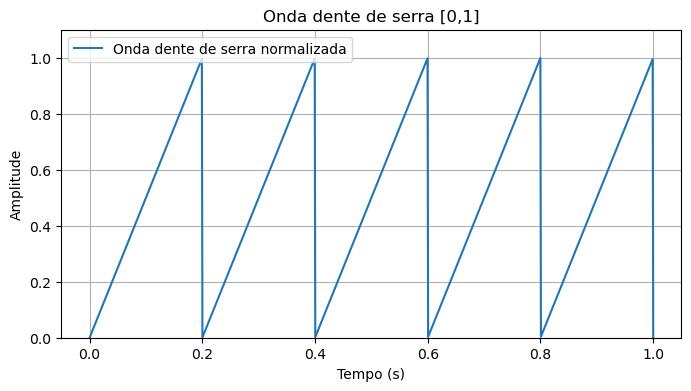

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth

# Parâmetros
fs = 1000        # taxa de amostragem (pontos por segundo)
f = 5            # frequência da onda (Hz)
t = np.linspace(0, 1, fs)  # vetor de tempo de 0 a 1 segundo

# Geração da onda dente de serra
# O parâmetro width=1 gera uma subida linear e queda abrupta
signal = sawtooth(2 * np.pi * f * t, width=1)

# Normalização para [0, 1]
signal_norm = (signal + 1) / 2

# Plotar o gráfico
plt.figure(figsize=(8, 4))
plt.plot(t, signal_norm, label="Onda dente de serra normalizada")
plt.title("Onda dente de serra [0,1]")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()


##### CONSTANTE:

BLOCO: const

obs.: principal ideia da const:
parametrizar nosso valor de duty cicl

- No bloco const basta especificar o valor especifico do duty cicle

Exemplo: 
duty cicle = $\frac{Taberta}{T}$





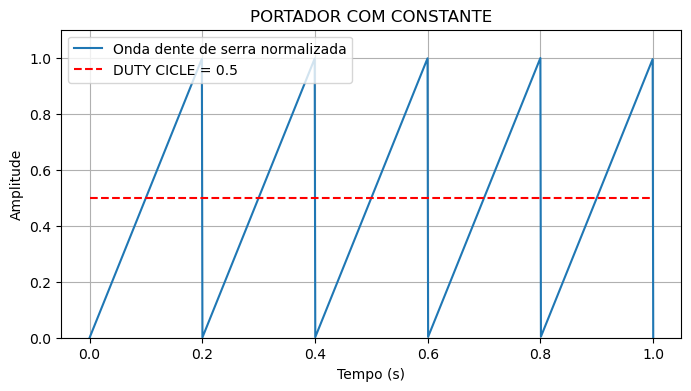

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth

# Parâmetros
fs = 1000        # taxa de amostragem (pontos por segundo)
f = 5            # frequência da onda (Hz)
t = np.linspace(0, 1, fs)  # vetor de tempo de 0 a 1 segundo

# Geração da onda dente de serra
signal = sawtooth(2 * np.pi * f * t, width=1)

# Normalização para [0, 1]
signal_norm = (signal + 1) / 2

# Sinal constante em 0.5
const_signal = np.full_like(t, 0.5)

# Plotar os gráficos sobrepostos
plt.figure(figsize=(8, 4))
plt.plot(t, signal_norm, label="Onda dente de serra normalizada")
plt.plot(t, const_signal, 'r--', label="DUTY CICLE = 0.5")
plt.title("PORTADOR COM CONSTANTE")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()


##### COMPARADOR:


BLOCO: Relational operator

Irá relacionar uma condição lógica comparativa entre a portadora e a constante.

geralmente >=

- const >= portador ---> output = 1

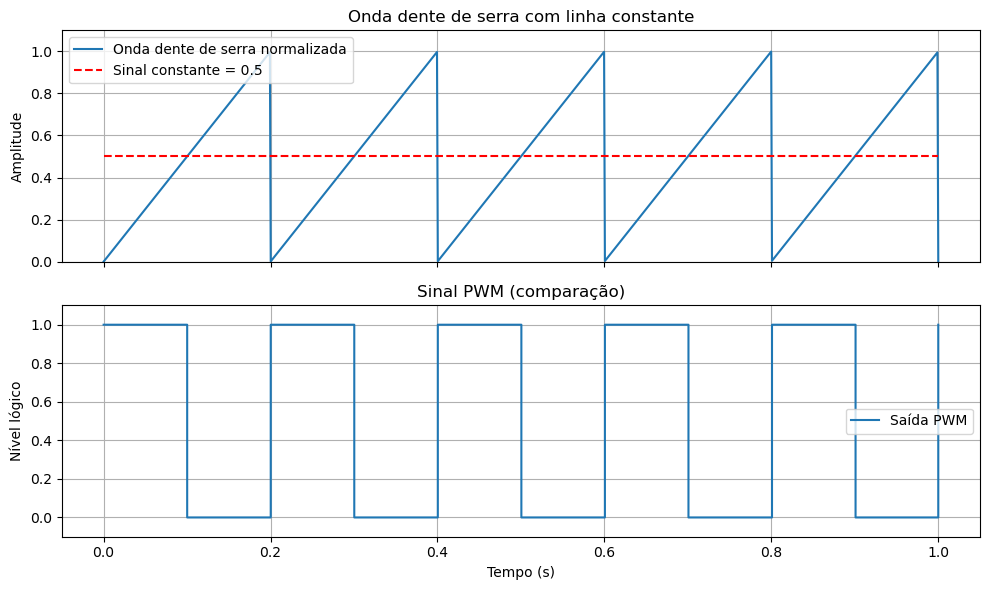

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth

# Parâmetros
fs = 1000        # taxa de amostragem (pontos por segundo)
f = 5            # frequência da onda (Hz)
t = np.linspace(0, 1, fs)  # vetor de tempo de 0 a 1 segundo

# Onda dente de serra
signal = sawtooth(2 * np.pi * f * t, width=1)
signal_norm = (signal + 1) / 2   # normalizada [0,1]

# Sinal constante
const_signal = np.full_like(t, 0.5)

# Modulação PWM: se constante >= dente de serra → 1, senão → 0
pwm = np.where(const_signal >= signal_norm, 1, 0)

# Criar subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Gráfico 1: onda dente de serra + linha constante
axs[0].plot(t, signal_norm, label="Onda dente de serra normalizada")
axs[0].plot(t, const_signal, 'r--', label="Sinal constante = 0.5")
axs[0].set_title("Onda dente de serra com linha constante")
axs[0].set_ylabel("Amplitude")
axs[0].set_ylim(0, 1.1)
axs[0].grid(True)
axs[0].legend()

# Gráfico 2: saída PWM
axs[1].step(t, pwm, where='post', label="Saída PWM")
axs[1].set_title("Sinal PWM (comparação)")
axs[1].set_xlabel("Tempo (s)")
axs[1].set_ylabel("Nível lógico")
axs[1].set_ylim(-0.1, 1.1)
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


##### TOLBOX

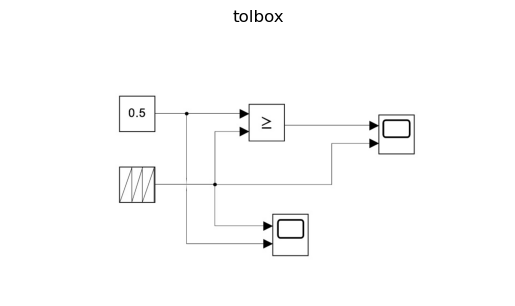

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Caminho da imagem (substitua pelo arquivo que você quer abrir)
img = mpimg.imread("blocos.jpeg")

# Mostrar a imagem
plt.imshow(img)
plt.axis("off")   # remove os eixos
plt.title("tolbox")
plt.show()
